In [11]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [12]:
iris = load_iris()

In [19]:
X = iris.data
y = iris.target

<Axes: >

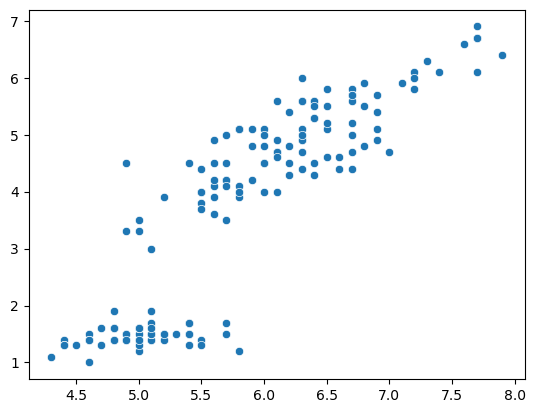

In [24]:
sns.scatterplot(x=X[:,0], y=X[:,2])

In [28]:
# Scaling

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [37]:
# optional -  dimensionality reduction using pca
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(X_scaled)

In [38]:
# elbow
wcss=[]

for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [39]:
wcss

[574.8792432000103,
 197.4038160454128,
 116.01774316704254,
 89.97446142147326,
 80.24797435025083,
 57.16006789670163,
 47.7085923955061,
 43.84367108903015,
 36.708105790788764,
 30.225044203969606]

<Axes: >

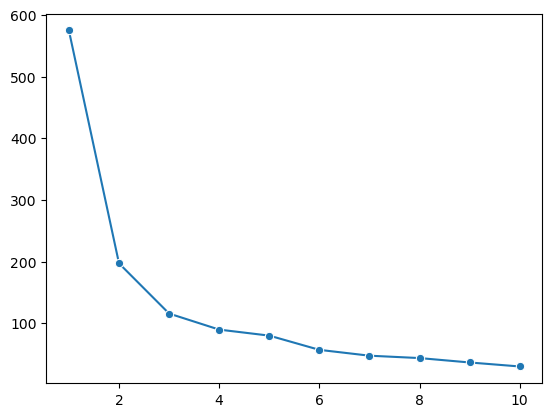

In [40]:
sns.lineplot(x=range(1,11),y=wcss,marker='o')

In [47]:
# kmeans

kmeans=KMeans(n_clusters=3 , random_state=10)
labels= kmeans.fit_predict(pca_data)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

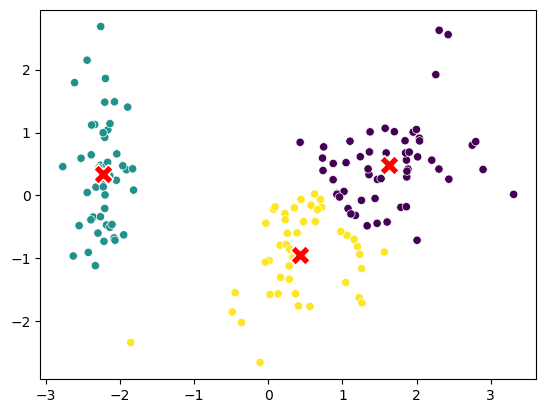

In [49]:
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:,1], c=labels)

#centroids
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], marker="X", c="red", s=200)